In [ ]:
Package Installation

In [1]:
import micropip
await micropip.install(['numpy', 'pandas', 'scikit-learn', 'matplotlib', 'seaborn'])
print("Packages installed ✅")

Packages installed ✅


In [ ]:
Extract The zipped folder

In [2]:
import zipfile, shutil, os

# Unzip the project
with zipfile.ZipFile('unsinkable_titanic_project.zip', 'r') as z:
    z.extractall('.')

# Copy train.csv into the project's data folder
shutil.copy('train.csv', 'unsinkable/data/train.csv')

# Confirm files are there
for item in os.listdir('unsinkable'):
    print("📁", item)

print("\nFiles ready ✅")

📁 README.md
📁 data
📁 notebooks
📁 report
📁 requirements.txt
📁 scripts
📁 {data,notebooks,scripts,report}

Files ready ✅


In [ ]:
Check working Directory

In [3]:
import sys, os

# Tell Python where your scripts are
sys.path.insert(0, 'unsinkable/scripts')
os.chdir('unsinkable')

print("Working directory:", os.getcwd(), "✅")

Working directory: /drive/unsinkable ✅


In [ ]:
Feature Engineering..!

In [9]:
from feature_engineering import engineer

df_eng = engineer(save=True)

print(f"Started with 11 features")
print(f"Now have: {df_eng.shape[1]} features")
print("\nPart 2 — Feature Engineering done ✅")

[engineer] input shape: (891, 14)
[engineer] output shape: (891, 38)
[engineer] features created: 38 columns
[saved] /drive/unsinkable/scripts/../data/train_engineered.csv
Started with 11 features
Now have: 38 features

Part 2 — Feature Engineering done ✅


In [ ]:
File Path correction

In [6]:
import os

# Show where Python is currently looking
print("Current location:", os.getcwd())
print()

# Show everything in the current folder
print("Files and folders here:")
for item in os.listdir('.'):
    print(" ", item)

Current location: /drive/unsinkable

Files and folders here:
  README.md
  data
  notebooks
  report
  requirements.txt
  scripts
  {data,notebooks,scripts,report}


In [ ]:
Fix file path issue

In [7]:
import sys, os

sys.path.insert(0, os.path.join(os.getcwd(), 'scripts'))

print("Python will now look in:", os.getcwd() + '/scripts')
print("Scripts visible:", os.path.exists('scripts'))

Python will now look in: /drive/unsinkable/scripts
Scripts visible: True


In [8]:
# This should print the contents of the scripts folder
print("Scripts found:")
for f in os.listdir('scripts'):
    print(" 📄", f)

Scripts found:
 📄 data_cleaning.py
 📄 feature_engineering.py
 📄 feature_selection.py


In [ ]:
Feature Selection

In [10]:
from feature_selection import select_features

selected = select_features()

print(f"\nFinal features chosen: {len(selected)}")
print("\nPart 3 — Feature Selection done ✅")

[select] Starting with 37 features
[corr_filter] Dropping 2 highly-correlated features: {'Sex_female', 'Deck_U'}
[select] After correlation filter: 35 features
[RF] 5-fold CV ROC-AUC: 0.7870 ± 0.0345

[select] Mean importance threshold: 0.0286
[select] Selected 12 features:

   1. Sex_male                            0.1760
   2. IsWoman_or_Child                    0.1137
   3. Title_Mr                            0.0974
   4. Age_x_Pclass                        0.0773
   5. LogFare                             0.0602
   6. Fare                                0.0572
   7. LogAge                              0.0529
   8. Age                                 0.0518
   9. FarePerPerson                       0.0518
  10. Pclass_x_Fare                       0.0484
  11. Title_Miss                          0.0453
  12. Title_Mrs                           0.0445

[saved] feature_importances.csv  |  selected_features.txt

Final features chosen: 12

Part 3 — Feature Selection done ✅


In [ ]:
Visualization by Chart

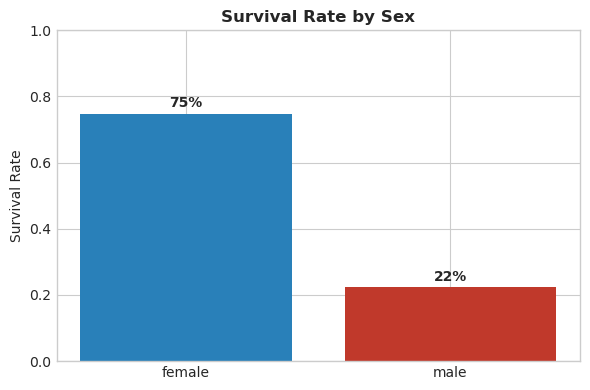

Chart displayed ✅


In [13]:
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')

# Chart: Survival rate by Sex
sex_surv = df_clean.groupby('Sex')['Survived'].mean()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(sex_surv.index, sex_surv.values, color=['#2980b9', '#c0392b'])
ax.set_title('Survival Rate by Sex', fontweight='bold')
ax.set_ylabel('Survival Rate')
ax.set_ylim(0, 1)
for i, v in enumerate(sex_surv.values):
    ax.text(i, v + 0.02, f'{v:.0%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print("Chart displayed ✅")

In [ ]:
Data Cleaning

In [12]:
import pandas as pd

# Reload the cleaned data from the file that was already saved
df_clean = pd.read_csv('data/train_cleaned.csv')

print(f"df_clean loaded ✅")
print(f"Shape: {df_clean.shape}")
print(f"Columns: {list(df_clean.columns)}")

df_clean loaded ✅
Shape: (891, 14)
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Age_was_missing', 'Cabin_known']


In [ ]:
Confirm if required files are present

In [14]:
import os

print("Files in data folder:")
for f in os.listdir('data'):
    print(" 📄", f)

Files in data folder:
 📄 feature_importances.csv
 📄 selected_features.txt
 📄 train.csv
 📄 train_cleaned.csv
 📄 train_engineered.csv
